# 03. Adjusting Hotline activity for population

The raw Hotline counts are useful, but they are difficult to compare fairly across states. California and Texas have much larger populations than states like Vermont or Wyoming, so I would expect them to generate more reports even if the underlying reporting patterns were similar.

To make the state comparisons more useful, I'm adding 2024 population estimates from the U.S. Census Bureau's American Community Survey.

I'll use population to calculate:

- signals received per 100,000 residents
- identified trafficking cases per 100,000 residents

These are reporting rates, not trafficking prevalence rates. A higher value means more Hotline activity relative to population, not necessarily that trafficking itself is more common.

In [2]:
import os
import pandas as pd
import requests

from pathlib import Path
from dotenv import load_dotenv


project_dir = Path.cwd()

if project_dir.name == "notebooks":
    project_dir = project_dir.parent


hotline_file = (
    project_dir
    / "data"
    / "cleaned"
    / "hotline_2024_states_dc.csv"
)

census_raw_dir = (
    project_dir
    / "data"
    / "raw"
    / "census"
)

census_raw_dir.mkdir(parents=True, exist_ok=True)


load_dotenv(project_dir / ".env")

census_key = os.getenv("CENSUS_API_KEY")


if not census_key:
    raise ValueError(
        "CENSUS_API_KEY was not found. Check the .env file in the project folder."
    )


hotline = pd.read_csv(
    hotline_file,
    dtype={"state_fips": "string"}
)


print(f"Hotline rows loaded: {len(hotline)}")
hotline.head()

Hotline rows loaded: 51


,state,signals_received,pct_total_signals,cases_identified,pct_total_cases,year,state_abbr,state_fips,signals_per_case,raw_case_rank
0,Alabama,231,0.71,105,0.87,2024,AL,01,2.20,30
1,Alaska,46,0.14,22,0.18,2024,AK,02,2.09,46
2,Arizona,550,1.70,300,2.50,2024,AZ,04,1.83,10
3,Arkansas,170,0.53,80,0.67,2024,AR,05,2.12,35
4,California,3378,10.46,1734,14.45,2024,CA,06,1.95,1


## Pulling state population estimates

I'm using the 2024 ACS 5-Year total population estimate (`B01003_001E`).

For this project, I prefer the 5-Year ACS because I may later bring in smaller geographic areas and additional demographic measures. Keeping the Census source consistent will make those later joins easier.

In [3]:
census_url = "https://api.census.gov/data/2024/acs/acs5"

census_params = {
    "get": "NAME,B01003_001E",
    "for": "state:*",
    "key": census_key
}


response = requests.get(
    census_url,
    params=census_params,
    timeout=60
)

response.raise_for_status()

census_json = response.json()


print(f"Rows returned by Census: {len(census_json) - 1}")
print("Census request successful.")

Rows returned by Census: 52
Census request successful.


## Turning the API response into a table

The Census API returns the column names as the first row of its response. I'm separating that header from the actual observations and then renaming the population field to something readable.

In [4]:
census_population = pd.DataFrame(
    census_json[1:],
    columns=census_json[0]
)


census_population = census_population.rename(
    columns={
        "NAME": "state_name_census",
        "B01003_001E": "population_2024",
        "state": "state_fips"
    }
)


census_population["state_fips"] = (
    census_population["state_fips"]
    .astype("string")
    .str.zfill(2)
)


census_population["population_2024"] = pd.to_numeric(
    census_population["population_2024"],
    errors="coerce"
)


census_population.head(10)

,state_name_census,population_2024,state_fips
0,Alabama,5086768,01
1,Alaska,735706,02
2,Arizona,7378838,04
3,Arkansas,3049391,05
4,California,39287377,06
5,Colorado,5862189,08
6,Connecticut,3624508,09
7,Delaware,1021191,10
8,District of Columbia,681294,11
9,Florida,22416077,12


## Saving the Census extract

I'm keeping a raw copy of the state population response before joining it to the Hotline data.

That gives me a clean separation between source data and the analysis-ready dataset.

In [5]:
census_raw_file = (
    census_raw_dir
    / "acs5_2024_state_population_raw.csv"
)


census_population.to_csv(
    census_raw_file,
    index=False
)


print(f"Saved Census population data to:\n{census_raw_file}")

Saved Census population data to:
c:\Users\skybo\OneDrive\Documents\human-trafficking-resource-gap-analysis\data\raw\census\acs5_2024_state_population_raw.csv


## Joining population to the Hotline data

Both datasets contain state FIPS codes, so I'm using those as the join key rather than relying on state-name spelling.

I'm keeping the Hotline dataset on the left side of the join because those 51 jurisdictions define the scope of this analysis.

In [6]:
state_data = hotline.merge(
    census_population[
        [
            "state_fips",
            "state_name_census",
            "population_2024"
        ]
    ],
    on="state_fips",
    how="left",
    validate="one_to_one"
)


join_check = pd.DataFrame({
    "check": [
        "Hotline rows before join",
        "rows after join",
        "states missing population",
        "duplicate states after join"
    ],
    "result": [
        len(hotline),
        len(state_data),
        state_data["population_2024"].isna().sum(),
        state_data["state"].duplicated().sum()
    ]
})


join_check

,check,result
0,Hotline rows before join,51
1,rows after join,51
2,states missing population,0
3,duplicate states after join,0


## Calculating reporting rates

I'm expressing the Hotline counts per 100,000 residents so the values are easier to compare across states.

The formula is:

**rate per 100,000 = reported count / population × 100,000**

I use the word "reported" intentionally. These measures describe Hotline activity relative to population and should not be interpreted as estimates of the number of trafficking victims in a state.

In [7]:
state_data["signals_per_100k"] = (
    state_data["signals_received"]
    / state_data["population_2024"]
    * 100_000
).round(2)


state_data["cases_per_100k"] = (
    state_data["cases_identified"]
    / state_data["population_2024"]
    * 100_000
).round(2)


state_data[
    [
        "state",
        "population_2024",
        "signals_received",
        "signals_per_100k",
        "cases_identified",
        "cases_per_100k"
    ]
].head(10)

,state,population_2024,signals_received,signals_per_100k,cases_identified,cases_per_100k
0,Alabama,5086768,231,4.54,105,2.06
1,Alaska,735706,46,6.25,22,2.99
2,Arizona,7378838,550,7.45,300,4.07
3,Arkansas,3049391,170,5.57,80,2.62
4,California,39287377,3378,8.60,1734,4.41
5,Colorado,5862189,465,7.93,185,3.16
6,Connecticut,3624508,167,4.61,96,2.65
7,Delaware,1021191,51,4.99,32,3.13
8,District of Columbia,681294,135,19.82,55,8.07
9,Florida,22416077,1830,8.16,832,3.71


## Raw counts versus population-adjusted rates

This is the comparison I'm most interested in at this stage.

If population matters as much as expected, the states with the largest raw case totals should not necessarily be the same states with the highest reported cases per 100,000 residents.

In [8]:
state_data["cases_per_100k_rank"] = (
    state_data["cases_per_100k"]
    .rank(
        method="min",
        ascending=False
    )
    .astype(int)
)


state_data["signals_per_100k_rank"] = (
    state_data["signals_per_100k"]
    .rank(
        method="min",
        ascending=False
    )
    .astype(int)
)


rate_ranking = (
    state_data[
        [
            "state",
            "state_abbr",
            "population_2024",
            "cases_identified",
            "raw_case_rank",
            "cases_per_100k",
            "cases_per_100k_rank"
        ]
    ]
    .sort_values("cases_per_100k_rank")
    .head(10)
    .reset_index(drop=True)
)


rate_ranking

,state,state_abbr,population_2024,cases_identified,raw_case_rank,cases_per_100k,cases_per_100k_rank
0,District of Columbia,DC,681294,55,38,8.07,1
1,Nevada,NV,3184612,236,15,7.41,2
2,Mississippi,MS,2946779,195,18,6.62,3
3,Texas,TX,30188424,1360,2,4.51,4
4,California,CA,39287377,1734,1,4.41,5
5,Missouri,MO,6191814,272,12,4.39,6
6,Kansas,KS,2947197,126,26,4.28,7
7,Arizona,AZ,7378838,300,10,4.07,8
8,Montana,MT,1116875,43,40,3.85,9
9,Hawaii,HI,1445235,55,38,3.81,10


## How much does the ranking change?

A state moving substantially after population adjustment is worth investigating.

I'm calculating the difference between its raw-case rank and its population-adjusted rank. This doesn't tell me why the difference exists, but it helps identify states that deserve a closer look.

In [9]:
state_data["rank_change_after_adjustment"] = (
    state_data["raw_case_rank"]
    - state_data["cases_per_100k_rank"]
)


biggest_rank_changes = (
    state_data[
        [
            "state",
            "raw_case_rank",
            "cases_per_100k_rank",
            "rank_change_after_adjustment",
            "cases_identified",
            "cases_per_100k"
        ]
    ]
    .assign(
        absolute_rank_change=lambda df:
            df["rank_change_after_adjustment"].abs()
    )
    .sort_values(
        "absolute_rank_change",
        ascending=False
    )
    .head(10)
    .reset_index(drop=True)
)


biggest_rank_changes

,state,raw_case_rank,cases_per_100k_rank,rank_change_after_adjustment,cases_identified,cases_per_100k,absolute_rank_change
0,District of Columbia,38,1,37,55,8.07,37
1,Pennsylvania,11,43,-32,287,2.20,32
2,Montana,40,9,31,43,3.85,31
3,South Dakota,43,12,31,34,3.75,31
4,New York,4,32,-28,570,2.87,28
5,Hawaii,38,10,28,55,3.81,28
6,North Carolina,9,34,-25,301,2.81,25
7,Ohio,8,33,-25,334,2.83,25
8,Delaware,44,19,25,32,3.13,25
9,Wyoming,50,27,23,17,2.92,23


## A quick visual check

I'm using a simple horizontal bar chart here rather than trying to make the notebook presentation-ready. The final visual design will happen in Power BI.

For now, I mainly want to see whether the highest population-adjusted reporting rates are heavily concentrated in a small number of jurisdictions.

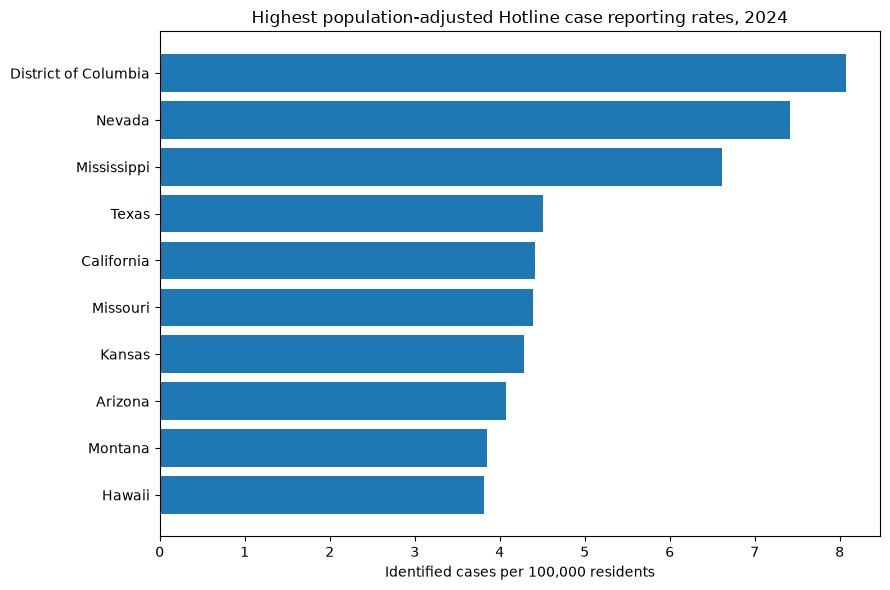

In [10]:
import matplotlib.pyplot as plt


top_rate_states = (
    state_data
    .sort_values(
        "cases_per_100k",
        ascending=False
    )
    .head(10)
    .sort_values("cases_per_100k")
)


plt.figure(figsize=(9, 6))

plt.barh(
    top_rate_states["state"],
    top_rate_states["cases_per_100k"]
)

plt.xlabel("Identified cases per 100,000 residents")
plt.ylabel("")
plt.title(
    "Highest population-adjusted Hotline case reporting rates, 2024"
)

plt.tight_layout()
plt.show()

## Saving the combined state dataset

This file now contains the Hotline measures, geographic identifiers, population estimates, and population-adjusted rates.

It will become one of the main tables used later in SQL and Power BI.

In [11]:
analysis_file = (
    project_dir
    / "data"
    / "cleaned"
    / "hotline_population_2024.csv"
)


state_data.to_csv(
    analysis_file,
    index=False
)


print(f"Saved analysis-ready state data to:\n{analysis_file}")

Saved analysis-ready state data to:
c:\Users\skybo\OneDrive\Documents\human-trafficking-resource-gap-analysis\data\cleaned\hotline_population_2024.csv
